# 10 · UNIFAC: predicting activity coefficients

Fitted models need data for every pair of substances - and industry works with thousands. UNIFAC sidesteps
the problem: a molecule is a collection of *groups* (CH$_3$, CH$_2$, OH, H$_2$O, ...), and the interactions between
groups, fitted once to a large database, predict the activity coefficients of any mixture built from them.
It is the standard first estimate when no data exist - for solvent selection, screening and preliminary design.

**What you will learn**
- describe molecules as UNIFAC groups
- predict activity coefficients without binary data
- judge UNIFAC's accuracy against data
- use infinite-dilution activity coefficients for solvent screening

**Before you start:** notebook 09  ·  **Time:** about 60 min

In [1]:
try:                      # on Google Colab (or anywhere engthermo is missing): install it from GitHub
    import engthermo
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engthermo"], check=True)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from engthermo import activity, datasets, unifac, vle
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

def heading(text):
    print(f"\n{text}\n" + "=" * len(text))

## Molecules as groups

In [2]:
for name in ("ethanol", "water", "acetone", "benzene", "n-hexane", "chloroform"):
    print(f"{name:<11}: {unifac.MOLECULES[name]}")
g = unifac.gammas(["ethanol", "water"], [0.4, 0.6], 351.0)
print(f"\nethanol-water at x = 0.4, 351 K: gamma = {g.round(3)}")

ethanol    : {'CH3': 1, 'CH2': 1, 'OH': 1}
water      : {'H2O': 1}
acetone    : {'CH3': 1, 'CH3CO': 1}
benzene    : {'ACH': 6}
n-hexane   : {'CH3': 2, 'CH2': 4}
chloroform : {'CHCL3': 1}

ethanol-water at x = 0.4, 351 K: gamma = [1.39  1.346]


## A genuine test: ethanol-water
The data file of notebook 09 was built from the experimental azeotrope and limiting activity coefficient,
*not* from UNIFAC - so this is a real prediction test:

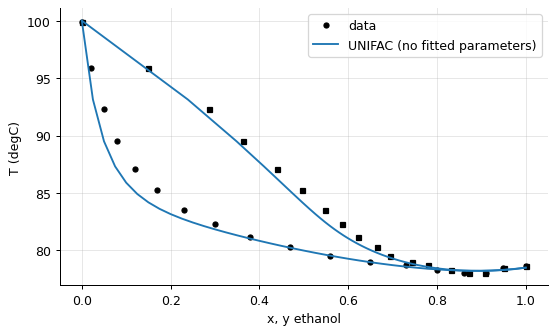

UNIFAC azeotrope: x = 0.891 at 78.21 degC (experimental 0.894, 78.15 degC)
errors against the data: T within 2.80 K, y within 0.061


In [3]:
d = pd.read_csv(datasets.path("ethanol_water_vle_1atm.csv"), comment="#")
comps, p = ["ethanol", "water"], 101325.0
g_uni = unifac.gamma_function(comps)
txy = vle.Txy(comps, p, g_uni, n=41)
plt.plot(d.x_ethanol, d.T_C, "ko", ms=4, label="data"); plt.plot(d.y_ethanol, d.T_C, "ks", ms=4)
plt.plot(txy["x1"], txy["T"] - 273.15, "C0", label="UNIFAC (no fitted parameters)"); plt.plot(txy["y1"], txy["T"] - 273.15, "C0")
plt.xlabel("x, y ethanol"); plt.ylabel("T (degC)"); plt.legend(); plt.show()
az = activity.azeotrope(comps, g_uni, p=p)
inner = d[(d.x_ethanol > 0) & (d.x_ethanol < 1)]
T_pred = np.array([vle.bubble_T(comps, [x, 1 - x], p, g_uni)["T"] - 273.15 for x in inner.x_ethanol])
y_pred = np.array([vle.bubble_T(comps, [x, 1 - x], p, g_uni)["y"][0] for x in inner.x_ethanol])
print(f"UNIFAC azeotrope: x = {az['x1']:.3f} at {az['T']-273.15:.2f} degC (experimental 0.894, 78.15 degC)")
print(f"errors against the data: T within {np.max(np.abs(T_pred - inner.T_C)):.2f} K, y within {np.max(np.abs(y_pred - inner.y_ethanol)):.3f}")

With no information about ethanol-water except the two molecules' groups, UNIFAC predicts the shape of the
diagram and the azeotrope to within 0.003 in composition and 0.1 K. Elsewhere it is less exact: bubble
temperatures deviate by up to 2.8 K and vapour compositions by up to 0.06, mostly at low ethanol content.
That is typical of UNIFAC - the right shape and the key features, with errors of a few percent in the
details. It is not a substitute for data in final design, but it is a remarkably good start.

## Positive and negative deviations

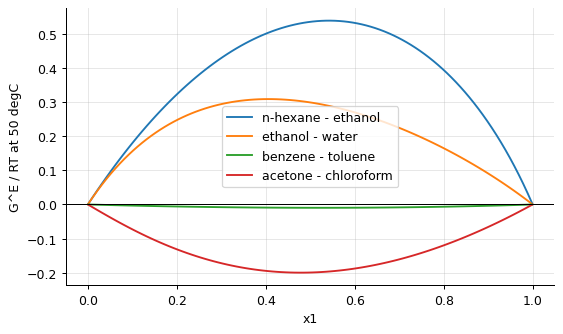

n-hexane in ethanol: gamma_inf = 7.33;  ethanol in n-hexane: 20.47
acetone in chloroform: gamma_inf = 0.46;  chloroform in acetone: 0.49


In [4]:
x = np.linspace(0.001, 0.999, 100)
fig, ax = plt.subplots()
for pair in (["n-hexane", "ethanol"], ["ethanol", "water"], ["benzene", "toluene"], ["acetone", "chloroform"]):
    ge = [activity.excess_gibbs(unifac.gamma_function(pair), [v, 1 - v], 323.15) for v in x]
    ax.plot(x, ge, label=f"{pair[0]} - {pair[1]}")
ax.axhline(0, color="k", lw=0.8); ax.set(xlabel="x1", ylabel="G^E / RT at 50 degC"); ax.legend(); plt.show()
for pair in (["n-hexane", "ethanol"], ["acetone", "chloroform"]):
    ginf = activity.infinite_dilution(unifac.gamma_function(pair), 323.15)
    print(f"{pair[0]} in {pair[1]}: gamma_inf = {ginf[0]:.2f};  {pair[1]} in {pair[0]}: {ginf[1]:.2f}")

Hexane-ethanol: strongly positive (the alcohol's hydrogen bonds exclude the alkane; a large limiting activity
coefficient hints at limited miscibility, notebook 12). Benzene-toluene: nearly zero, as Raoult's law assumed.
Acetone-chloroform: **negative** deviations - the C-H of chloroform hydrogen-bonds to the ketone oxygen, the
molecules attract each other more than themselves, and the mixture has a *maximum*-boiling azeotrope.

## Solvent screening
Which solvent extracts acetone from water best? A low activity coefficient of acetone in the solvent means a
high affinity:

In [5]:
rows = []
for solvent in ("water", "benzene", "toluene", "n-hexane", "chloroform", "ethyl acetate", "1-butanol"):
    ginf = activity.infinite_dilution(unifac.gamma_function(["acetone", solvent]), 298.15)[0]
    rows.append((solvent, ginf))
print(pd.DataFrame(rows, columns=["solvent", "gamma_inf of acetone at 25 degC"]).sort_values("gamma_inf of acetone at 25 degC").round(2).to_string(index=False))

      solvent  gamma_inf of acetone at 25 degC
   chloroform                             0.37
ethyl acetate                             1.30
      toluene                             1.46
      benzene                             1.53
    1-butanol                             2.05
     n-hexane                             6.28
        water                            11.47


Chloroform's affinity for acetone (activity coefficient below 1) is the hydrogen bond above; the alkane's is
poor. Screening hundreds of candidate solvents this way, before any experiment, is UNIFAC's everyday job in
process development - followed by measurements on the shortlist.

## Inside the algorithm: the combinatorial part
UNIFAC's combinatorial term depends only on sizes and shapes: $\ln\gamma_i^C = \ln(\Phi_i/x_i) + 5q_i\ln(\theta_i/\Phi_i) + l_i - (\Phi_i/x_i)\sum_j x_jl_j$,
with $r_i = \sum\nu_kR_k$ and $q_i = \sum\nu_kQ_k$ from the group tables:

In [6]:
from engthermo._unifac_data import SUBGROUPS
def r_q(mol):
    ids = unifac.groups(mol)
    return sum(n * SUBGROUPS[k][3] for k, n in ids.items()), sum(n * SUBGROUPS[k][4] for k, n in ids.items())
r1, q1 = r_q("ethanol"); r2, q2 = r_q("water")
x1_, x2_ = 0.4, 0.6
r_, q_ = np.array([r1, r2]), np.array([q1, q2]); x_ = np.array([x1_, x2_])
Phi, Th = r_ * x_ / (r_ @ x_), q_ * x_ / (q_ @ x_)
l_ = 5 * (r_ - q_) - (r_ - 1)
lnC = np.log(Phi / x_) + 5 * q_ * np.log(Th / Phi) + l_ - Phi / x_ * (x_ @ l_)
print(f"ethanol: r = {r1:.4f}, q = {q1:.3f}; water: r = {r2:.4f}, q = {q2:.3f}; combinatorial gammas at x = 0.4: {np.exp(lnC).round(4)}")

ethanol: r = 2.5755, q = 2.588; water: r = 0.9200, q = 1.400; combinatorial gammas at x = 0.4: [1.0469 1.081 ]


## Exercises
1. Predict the T-x-y diagram of acetone-methanol at 1 atm with UNIFAC and locate its azeotrope. (Experimental: about 0.80 mole fraction acetone at 55.7 degC.)
2. Use UNIFAC to rank benzene, toluene, n-hexane and 1-butanol as solvents for extracting ethanol from water at 25 degC, and comment on the trade-off between affinity and the solvent's own solubility in water.
3. **Implement it yourself:** compute the infinite-dilution activity coefficient of ethanol in water at 351 K by evaluating UNIFAC at x = 1e-6, and compare with the value extracted from the data file's first points.